# 快速入门指南

欢迎使用 `pi-oplsda`！这是一个正交偏最小二乘判别分析（OPLS-DA）Python 工具包，专门为实现与广泛使用的 R 语言包 `ropls` 的对齐而设计。

本教程将引导您逐步构建一个完整的分析流程。您将学习如何加载数据、拟合 OPLS-DA 模型、通过置换检验评估其性能，并生成出版级别的诊断可视化图表。我们将使用一个内置的代谢组学基准数据集来进行标准的二分类任务。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import piopls
from piopls import OPLSDA, OPLSDA_Visualizer
from piopls import load_sacurine

# 打印已安装的 pi-oplsda 版本以确保兼容性
print(f"pi-oplsda version: {piopls.__version__}")

pi-oplsda version: 0.1.2


## 1. 加载基准数据集 (Sacurine)
`sacurine` 数据集是一个经典的人类尿液代谢组学数据集，包含 183 个样本和 109 个代谢物特征。 

目标响应变量 `y` 代表个体的性别（`M` 代表男性，`F` 代表女性）。这使得我们的实验设置成为一个标准的**二分类（两组）设计**，这也是 OPLS-DA 在生物标志物发现中最常见的用例。

In [3]:
# 加载内置的演示数据集。
# 函数 load_sacurine() 返回四个变量：
# 1. X: 特征矩阵 (样本数 x 代谢物数)
# 2. y: 目标数组 (每个样本的类别标签)
# 3. feature_names: 109 个代谢物的名称或 ID
# 4. sample_names: 183 个样本的唯一标识符
X, y, feature_names, sample_names = load_sacurine()

# 验证我们加载的数据的维度
print(f"Feature matrix X shape: {X.shape}")
print(f"Target array y shape: {y.shape}")
print(f"Unique classes in y: {np.unique(y)}")

Feature matrix X shape: (183, 109)
Target array y shape: (183,)
Unique classes in y: ['F' 'M']


## 2. 二分类设计：OPLS-DA 分析
对于代谢组学中的两组比较，**OPLS-DA** 被认为是金标准算法。 

与标准的 PCA 或 PLS-DA 不同，OPLS-DA 能够有效地滤除正交噪声——即数据集中与组别标签完全无关的变异（例如，技术批次效应或组内个体差异）。通过将这些噪声推至正交主成分中，预测主成分变得更加干净，从而能够更精确、更具解释性地识别差异代谢物（生物标志物）。

### 2.1 执行 OPLS-DA 建模与置换检验
在这里，我们实例化 `OPLSDA` 模型。
关键参数是 `n_ortho`（正交主成分的数量），通过设置 `n_ortho=None`可指示模型通过交叉验证使用 Q2 启发式算法自动确定最佳的正交主成分数量。

拟合模型后，执行并行的**置换检验 (Permutation Test)**，从统计学上验证我们的模型是稳健的且没有过拟合。

In [4]:
# 1. 加载 DataFrame
# (在这个特定的例子中，我们直接从 CSV 文件加载以演示如何使用 pandas DataFrames)
df_X = pd.read_csv("../src/piopls/data/sacurine_X.csv", index_col=[0])
df_Y = pd.read_csv("../src/piopls/data/sacurine_Y.csv", index_col=[0])
y_data = df_Y.iloc[:, 0].values 

# 2. 模型配置与计算
# cv_folds: 交叉验证的折数
# max_ortho: 如果 n_ortho 为 None，自动搜索的最大正交主成分数
# n_perms: 验证检验的置换次数
# n_jobs: -1 表示使用所有可用的 CPU 核心进行并行置换检验
model_opls = OPLSDA(
    cv_folds=7,
    max_ortho=10, 
    n_perms=100, 
    n_jobs=-1
)

# 将 OPLS-DA 模型拟合到数据上
model_opls.fit(df_X, y_data)

# 计算交叉验证的 Q2 指标（预测能力）
model_opls.compute_q2(df_X, y_data) 

# 执行置换检验以评估 R2Y 和 Q2 的统计显著性
perm_results = model_opls.permutation_test(
    df_X,
    y_data
)

# 3. 初始化可视化器
# 接收已拟合的模型和真实的标签，以准备绘图环境。
# vip_threshold: 用于在 S-Plot 中突出显示重要特征的阈值
# top_n_vip: VIP 条形图中显示的顶级特征数量
vis_opls = OPLSDA_Visualizer(
    model=model_opls, 
    y=y_data, 
    feature_names=None, 
    sample_names=None, 
    vip_threshold=1.0, 
    top_n_vip=15, 
    custom_palette=None
)

Permutation Test: 100%|██████████████████████████████████████████████████| 100/100 [00:12<00:00,  7.72it/s]


### 2.2 将模型指标导出为 DataFrames
`pi-oplsda` 允许用户将关键参数导出为格式化的 `pandas.DataFrame` 对象，提取全局汇总、逐个主成分的方差解释、样本得分以及特征选择指标（例如，VIP 分数、协方差、相关系数）。

In [5]:
# 获取模型元数据的全局概览 (与 ropls 的 getSummaryDF 对应)
# 显示 N_Predictive, N_Ortho, 累积的 R2X/R2Y/Q2, RMSEE, 以及置换检验的 p 值
display(model_opls.get_model_info_df())

# 获取逐步汇总 dataframe，显示每个主成分 (p1, o1, o2...) 的增量方差解释率
display(model_opls.get_summary_df())

# 获取样本的模型得分 dataframe
# 提供 y_true 可以生成 'Match_Status' 列以标记错误分类的样本
display(model_opls.get_scores_df(y_true=y_data))

# 获取特征选择 dataframe
# 包含 VIP 分数、协方差 (p1) 和 相关系数 (pcorr1)，并按 VIP 降序排列
display(model_opls.get_features_df())


,N_Predictive,N_Ortho,R2X(cum),R2Y(cum),Q2(cum),RMSEE,pR2Y,pQ2
0,1,2,0.275229,0.729833,0.592026,0.258764,0.009901,0.009901


,Component,R2X,R2Y,Q2,R2X(cum),R2Y(cum),Q2(cum)
0,p1,0.098442,0.479107,0.401144,0.098442,0.479107,0.401144
1,o1,0.086129,0.189217,0.243941,0.184571,0.668324,0.547230
2,o2,0.090658,0.061509,0.098938,0.275229,0.729833,0.592026


,Sample,t_pred,t_ortho_1,t_ortho_2,True_Class,Fitted_Value,Fitted_Class,Match_Status
0,HU_011,1.582933,4.980604,-5.268184,M,0.841541,M,Matched
1,HU_014,-1.372806,1.744338,-0.892428,F,0.290528,F,Matched
2,HU_015,3.341370,3.437277,-2.477440,M,1.169351,M,Matched
3,HU_017,3.590063,0.979496,-3.557066,M,1.215713,M,Matched
4,HU_018,1.662716,-0.315585,3.628218,M,0.856414,M,Matched
...,...,...,...,...,...,...,...,...
178,HU_205,3.020039,0.185278,2.136284,M,1.109448,M,Matched
179,HU_206,-0.238014,-1.022405,3.789028,F,0.502077,M,Mismatched
180,HU_207,-4.860766,-3.253181,0.538034,F,-0.359703,F,Matched
181,HU_208,-1.095204,-5.730609,-0.108418,F,0.342278,F,Matched


,Feature,VIP,Covariance (p1),Correlation (pcorr1),Loading_Weight
0,Testosterone glucuronide,2.968444,0.720792,0.541128,0.236541
1,Malic acid,2.854745,-0.320155,-0.554021,-0.242177
2,Oxoglutaric acid,2.729234,-0.373103,-0.381218,-0.166640
3,p-Anisic acid,2.616747,-1.393154,-0.566073,-0.247445
4,Pantothenic acid,2.486306,-0.282849,-0.483856,-0.211506
...,...,...,...,...,...
104,Threonic acid/Erythronic acid,0.069829,-0.111055,-0.272778,-0.119238
105,Cinnamoylglycine,0.066640,-0.195496,-0.178481,-0.078019
106,"1,7-Dimethyluric acid",0.054264,0.007197,0.007357,0.003216
107,Glycocholic acid isomer 2,0.047033,-0.003799,-0.002368,-0.001035


### 2.3 生成诊断图表 (全局布局)
只需一行代码，我们就可以在一个图表中生成所有五种标准的出版级别诊断图表：
1. **模型概览 (Model Overview)**: 每个主成分的 R2Y 和 Q2 指标。
2. **X 得分图 (X-Score Plot)**: 可视化组间分离和组内方差（带有置信椭圆）。
3. **VIP 条形图 (VIP Bar Plot)**: 对最重要的差异代谢物进行排名。
4. **置换检验图 (Permutation Test Plot)**: 验证模型是否未过拟合。
5. **S-图 (S-Plot)**: 映射协方差与相关系数，以识别高置信度的生物标志物。

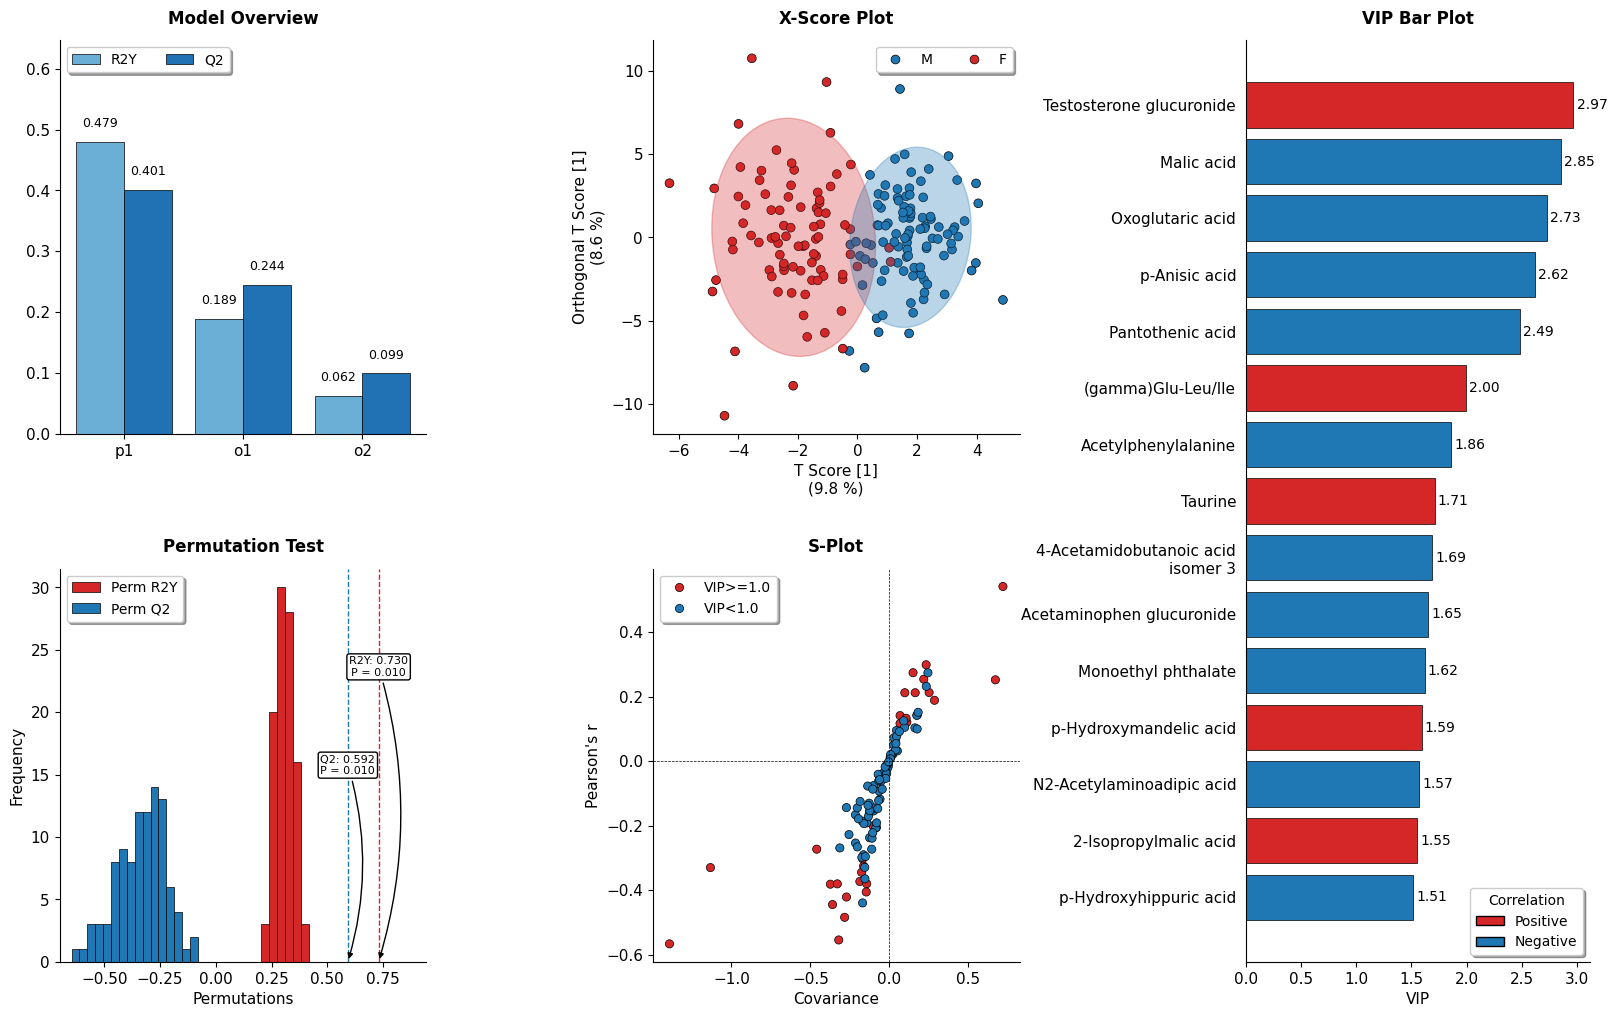

In [6]:
# 在一个统一的网格布局中生成并显示所有诊断图表。
# 我们传入 perm_results 以启用置换检验图。
# wrap_width 自动处理 VIP 图中过长的代谢物名称。
# figsize 可以显式设置以适应特定期刊的栏宽。
vis_opls.plot_all(
    perm_results=perm_results, 
    wrap_width=30,
    figsize=(16, 10)
)


### 2.4 进阶：绘制并自定义单个子图
`pi-oplsda` 支持提取单个子图，实现局部的样式更改。

因为 `pi-oplsda` 完全建立在面向对象的 Matplotlib 架构之上，所以您可以将特定的 `ax`（坐标轴对象）传递给任何绘图函数并手动覆盖其属性。

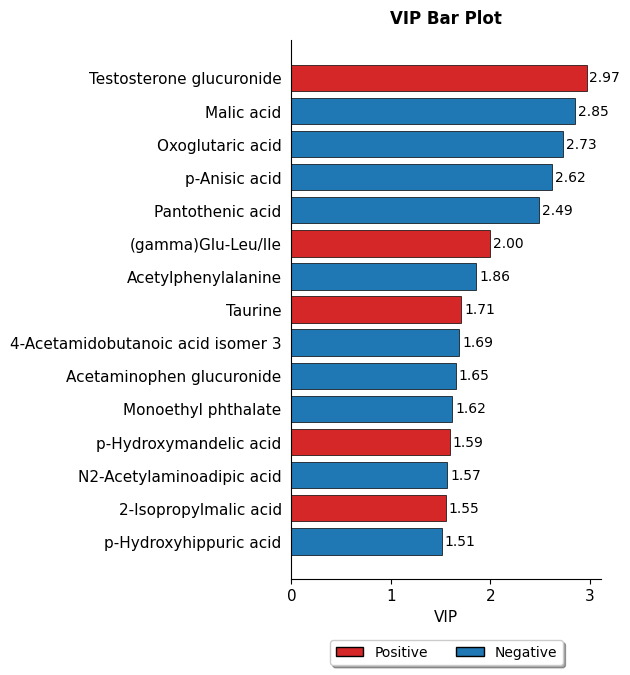

In [10]:
import matplotlib.pyplot as plt

# =====================================================================
# 示例 A: 带有自定义图例重新定位的独立 VIP 图
# =====================================================================

# 1. 创建一个具有特定高纵横比的独立图形
fig_vip, ax_vip = plt.subplots(figsize=(4, 7))

# 2. 仅在此坐标轴上绘制 VIP 条形图
vis_opls.plot_vip_bar(ax=ax_vip, wrap_width=45)

# 3. 高级自定义: 提取默认图例并将其移到外部
old_legend = ax_vip.get_legend()
if old_legend is not None:
    handles = old_legend.legend_handles
    labels = [text.get_text() for text in old_legend.get_texts()]
    title = old_legend.get_title().get_text()
    
    # 重新绘制图例，强制其成为一个双列的水平布局，
    # 并锚定在主绘图区外部的底部中心。
    ax_vip.legend(
        handles=handles,
        labels=labels,
        title="",
        loc='upper center',          
        bbox_to_anchor=(0.5, -0.1),
        ncol=2,                      
        frameon=True, 
        shadow=True, 
        fontsize=10, 
        facecolor="white"
    )

# 确保新放置的外部图例不会从图形中被裁剪掉
plt.show()

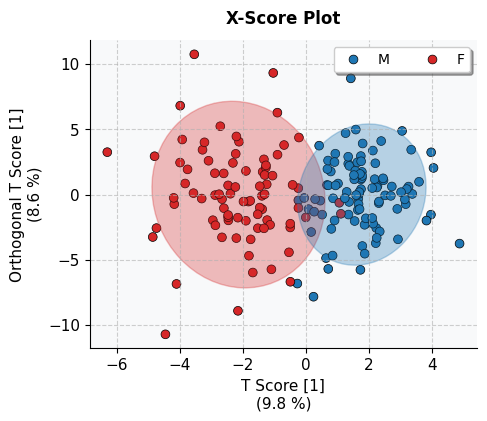

In [12]:
# =====================================================================
# 示例 B: 带有局部样式修改的独立得分图 (Score Plot)
# =====================================================================

fig_score, ax_score = plt.subplots(figsize=(5, 4))

# 仅绘制得分散点图
vis_opls.plot_score(ax=ax_score)

# 局部覆盖 1: 添加网格线 (默认情况下不存在)
ax_score.grid(True, linestyle='--', alpha=0.6, zorder=0)

# 局部覆盖 2: 专门为此图添加柔和的背景颜色
ax_score.set_facecolor('#f8f9fa')

plt.show()